# Homework06

Exercises to practice pandas, data analysis and regression

## Goals

- Understand the effects of pre-processing data
- Get familiar with the ML flow: encode -> normalize -> train -> evaluate
- Understand the difference between regression and classification tasks
- Build intuition for different regression models

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework.

In [1]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor

from data_utils import object_from_json_url
from data_utils import regression_error

### Load Dataset

Let's load up the full [ANSUR](https://www.openlab.psu.edu/ansur2/) dataset that we looked at briefly in [Week 02](https://github.com/DM-GY-9103-2024F-H/WK02).

This is the dataset that has anthropometric information about U.S. Army personnel.

#### WARNING

Like we mentioned in class, this dataset is being used for these exercises due to the level of detail in the dataset and the rigorous process that was used in collecting the data.

This is a very specific dataset and should not be used to draw general conclusions about people, bodies, or anything else that is not related to the distribution of physical features of U.S. Army personnel.

In [26]:
# Load Dataset
ANSUR_FILE = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/main/datasets/json/ansur.json"
ansur_data = object_from_json_url(ANSUR_FILE)

# Look at first 2 records
ansur_data[:2]

[{'age': 18,
  'gender': 'F',
  'height': 66,
  'weight': 135,
  'span': 1699,
  'stature': 1645,
  'ear': {'breadth': 30, 'length': 61, 'protrusion': 20},
  'foot': {'breadth': 97, 'length': 243},
  'hand': {'breadth': 78, 'length': 182, 'palm': 108},
  'head': {'height': 243, 'circumference': 557}},
 {'age': 30,
  'gender': 'M',
  'height': 68,
  'weight': 207,
  'span': 1749,
  'stature': 1715,
  'ear': {'breadth': 35, 'length': 63, 'protrusion': 17},
  'foot': {'breadth': 100, 'length': 252},
  'hand': {'breadth': 87, 'length': 184, 'palm': 114},
  'head': {'height': 238, 'circumference': 560}}]

#### Nested data

This is that *nested* dataset from Week 02.

# 🤔

Let's load it into a `DataFrame` to see what happens.

In [27]:
# Read into DataFrame
ansur_df = pd.DataFrame.from_records(ansur_data)
ansur_df.head()

,age,gender,height,weight,span,stature,ear,foot,hand,head
0,18,F,66,135,1699,1645,"{'breadth': 30, 'length': 61, 'protrusion': 20}","{'breadth': 97, 'length': 243}","{'breadth': 78, 'length': 182, 'palm': 108}","{'height': 243, 'circumference': 557}"
1,30,M,68,207,1749,1715,"{'breadth': 35, 'length': 63, 'protrusion': 17}","{'breadth': 100, 'length': 252}","{'breadth': 87, 'length': 184, 'palm': 114}","{'height': 238, 'circumference': 560}"
2,27,M,67,121,1684,1657,"{'breadth': 36, 'length': 59, 'protrusion': 24}","{'breadth': 92, 'length': 251}","{'breadth': 84, 'length': 180, 'palm': 103}","{'height': 239, 'circumference': 516}"
3,20,M,73,185,1878,1828,"{'breadth': 36, 'length': 60, 'protrusion': 21}","{'breadth': 104, 'length': 280}","{'breadth': 95, 'length': 201, 'palm': 124}","{'height': 270, 'circumference': 582}"
4,33,M,76,150,1977,1883,"{'breadth': 39, 'length': 65, 'protrusion': 27}","{'breadth': 101, 'length': 271}","{'breadth': 90, 'length': 194, 'palm': 113}","{'height': 254, 'circumference': 559}"



# 😓🙄

That didn't work too well. We ended up with objects in our columns.

Luckily, our `DataFrame` library has a function called [`json_normalize()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.json_normalize.html) that can help.

In [28]:
# Read into DataFrame
ansur_df = pd.json_normalize(ansur_data)
ansur_df.head()

,age,gender,height,weight,span,stature,ear.breadth,ear.length,ear.protrusion,foot.breadth,foot.length,hand.breadth,hand.length,hand.palm,head.height,head.circumference
0,18,F,66,135,1699,1645,30,61,20,97,243,78,182,108,243,557
1,30,M,68,207,1749,1715,35,63,17,100,252,87,184,114,238,560
2,27,M,67,121,1684,1657,36,59,24,92,251,84,180,103,239,516
3,20,M,73,185,1878,1828,36,60,21,104,280,95,201,124,270,582
4,33,M,76,150,1977,1883,39,65,27,101,271,90,194,113,254,559


Much better. `DataFrames` are magic.

#### Data Exploration

Before we start creating models, let's do a little bit of data analysis and get a feeling for the shapes, distributions and relationships of our data.

1. Print `min`, `max` and `average` values for all of the features.
2. Print `covariance` tables for `age`, `ear.length` and `head.circumference`.
3. Plot `age`, `ear.length` and `head.circumference` versus the $1$ *feature* that is most correlated to each of them.

Don't forget to *encode* and *normalize* the data.

age 
	min: 17
	max: 58
	avg: 29.745
gender 
	min: 0.0
	max: 1.0
	avg: 0.673
height 
	min: 56
	max: 94
	avg: 68.247
weight 
	min: 0
	max: 321
	avg: 174.558
span 
	min: 1323
	max: 2121
	avg: 1763.703
stature 
	min: 1409
	max: 1993
	avg: 1714.265
ear.breadth 
	min: 25
	max: 46
	avg: 35.129
ear.length 
	min: 46
	max: 81
	avg: 62.637
ear.protrusion 
	min: 13
	max: 34
	avg: 22.267
foot.breadth 
	min: 77
	max: 126
	avg: 98.851
foot.length 
	min: 198
	max: 323
	avg: 262.992
hand.breadth 
	min: 67
	max: 105
	avg: 84.937
hand.length 
	min: 145
	max: 239
	avg: 189.26
hand.palm 
	min: 88
	max: 140
	avg: 113.92
head.height 
	min: 206
	max: 295
	avg: 249.171
head.circumference 
	min: 502
	max: 635
	avg: 570.063
                         age  ear.length  head.circumference
age                 1.000179    0.292098            0.014044
ear.length          0.292098    1.000179            0.283878
head.circumference  0.014044    0.283878            1.000179


<function matplotlib.pyplot.show(close=None, block=None)>

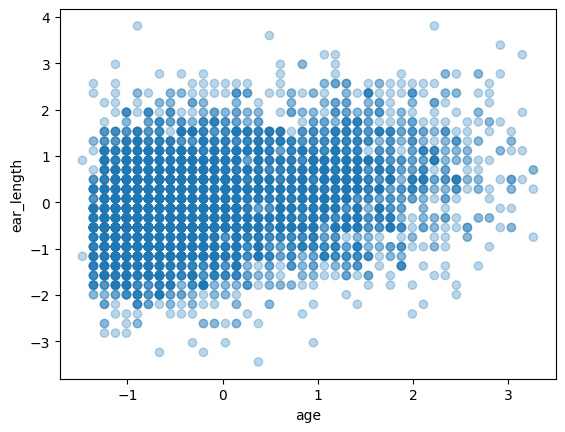

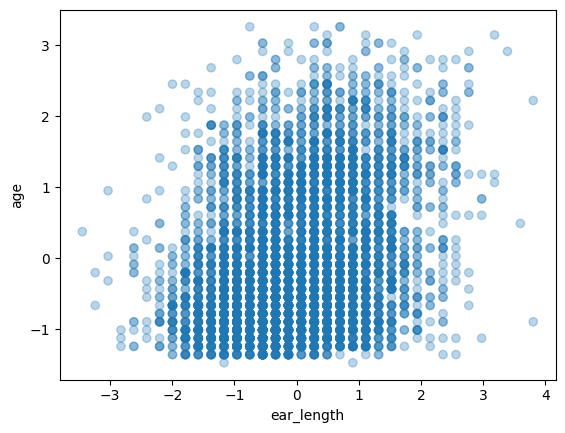

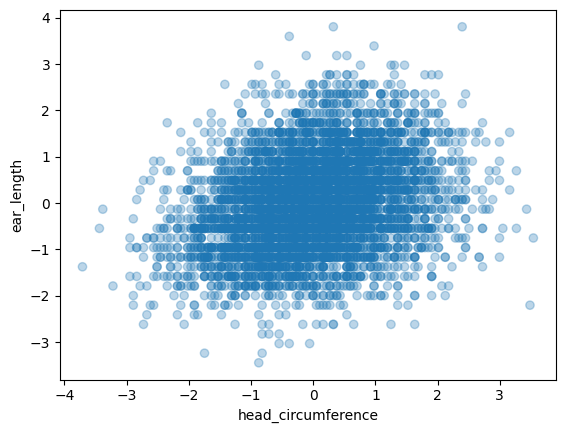

In [29]:
# Work on Data Exploration here

### Encode non-numerical features
gender = ['F', 'M']
gender_encoder = OrdinalEncoder(categories=[gender])
ansur_df[["gender"]] = gender_encoder.fit_transform(ansur_df[["gender"]].values)

## 1. Print min, max, avg
for c in ansur_df.select_dtypes(include="number").columns:
   print(c, "\n\tmin:", ansur_df[c].min())
   print("\tmax:", ansur_df[c].max())
   print("\tavg:", round(ansur_df[c].mean(), 3))

### Normalize all data
ansur_scaler = StandardScaler().set_output(transform="pandas")
ansur_scaled_df = ansur_scaler.fit_transform(ansur_df)


## 2. Print Covariances
cols = ["age", "ear.length", "head.circumference"]
print(ansur_scaled_df[cols].cov())


## 3. Plot features most correlated to age, ear length and head circumference
age = ansur_scaled_df[["age"]]
ear_length = ansur_scaled_df[["ear.length"]]
head_cir = ansur_scaled_df[["head.circumference"]]

plt.figure()
plt.scatter(age, ear_length, marker="o", linestyle='', alpha=0.3)
plt.xlabel("age")
plt.ylabel("ear_length")
plt.show

plt.figure()
plt.scatter(ear_length, age, marker="o", linestyle='', alpha=0.3)
plt.ylabel("age")
plt.xlabel("ear_length")
plt.show

plt.figure()
plt.scatter(head_cir, ear_length, marker="o", linestyle='', alpha=0.3)
plt.xlabel("head_circumference")
plt.ylabel("ear_length")
plt.show


### Interpretation

<span style="color:hotpink;">
Does anything stand out about these graphs? Or the correlations?<br>
Are correlations symmetric? Does the feature most correlated to ear length also have ear length as its most correlated pair?
</span>

<span style="color:hotpink;">EDIT THIS CELL WITH ANSWER</span> <br>
There are positive correlations in all the graphs although none of them are strong.
The feature most correlatd to ear length is age, which also has ear length as its most correlated pair.

### Regression

Now, we want to create a regression model to predict `head.circumference` from the data.

From our [Week 06](https://github.com/PSAM-5020-2026S-A/WK06) notebook, we can create a regression model by following these steps:

1. Load dataset (done! 🎉)
2. Encode label features as numbers (done! ⚡️)
3. Normalize the data (done! 🍾)
4. Separate the outcome variable and the input features
5. Create a regression model using all features
6. Run model on training data and measure error
7. Plot predictions and interpret results
8. Run model on test data, measure error, plot predictions, interpret results

13.910571985204237


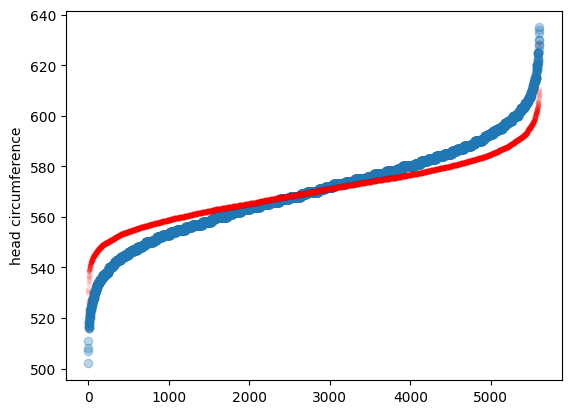

In [42]:
# Work on Regression Model here

## Separate outcome variable and input features
features_df = ansur_scaled_df.drop(columns=["head.circumference"])
out_df = ansur_df[["head.circumference"]]


## Create a regression model
head_cir_model = LinearRegression().fit(features_df, out_df)

## Measure error on training data
predicted_head_cir = head_cir_model.predict(features_df)

train_error = regression_error(out_df, predicted_head_cir)
print(train_error)

## Plot predictions and interpret results
head_original = sorted(ansur_df["head.circumference"])
head_predicted = sorted(predicted_head_cir)

plt.plot(head_original, marker='o', linestyle='', alpha=0.3)
plt.plot(head_predicted, color='r', marker='o', markersize='3', linestyle='', alpha=0.1)
plt.ylabel("head circumference")
plt.show()

In [33]:
## Load Test Data
ANSUR_TEST_FILE = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/main/datasets/json/ansur-test.json"

ansur_test_data = object_from_json_url(ANSUR_TEST_FILE)
ansur_test_df = pd.json_normalize(ansur_test_data)

ansur_test_encoded_df = ansur_test_df.copy()

g_vals = gender_encoder.transform(ansur_test_df[["gender"]])
ansur_test_encoded_df[["gender"]] = g_vals

ansur_test_scaled_df = ansur_scaler.transform(ansur_test_encoded_df)

/usr/local/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but OrdinalEncoder was fitted without feature names
  warnings.warn(


14.473238058423497


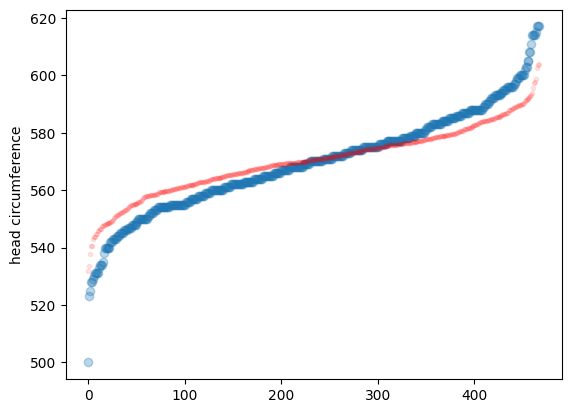

In [43]:
## Run model on test data
test_features_df = ansur_test_scaled_df.drop(columns=["head.circumference"])
test_predict = head_cir_model.predict(test_features_df)

## Measure error on test data
test_error = regression_error(ansur_test_df["head.circumference"], test_predict)
print(test_error)


## Plot predictions and interpret results
head_test_original = sorted(ansur_test_df["head.circumference"])
head_test_predicted = sorted(test_predict)

plt.plot(head_test_original, marker='o', linestyle='', alpha=0.3)
plt.plot(head_test_predicted, color='r', marker='o', markersize='3', linestyle='', alpha=0.1)
plt.ylabel("head circumference")
plt.show()


### Interpretation

<span style="color:hotpink;">
How well does your model perform?<br>
How could you improve it?<br>
Are there ranges of circumferences that don't get predicted well?
</span>

<span style="color:hotpink;">EDIT THIS CELL WITH ANSWER</span> <br>
My model performed well overall, but there are more gaps between the actual and prediction at the lowest end and highest end of head circumference. I can potentially improve the model by including quadratic terms or cubic terms since the predicted results are a bit too flat right now